In [ ]:
import cv2
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if ret == True:
        cv2.imshow('Stream de prueba', frame)

    else:
        break

cap.relase()
cv2.destroyAllWindows()

In [12]:
import cv2
img = cv2.imread('img/rojo.png', 2)
cv2.imshow('imagen', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

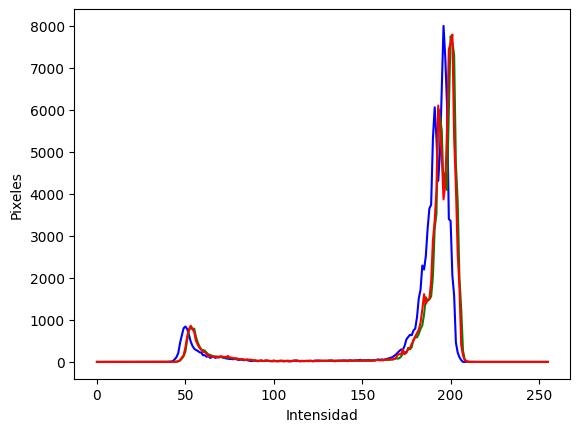

'\n        En un primer momento creia que podria aislar un punto rojo\n    en base a buscar donde la intensidad de los pixeles, en el canal RED, sea mayor \n    en la imagen. Esto tiene un inconveniente: el blanco tiene una alta intencidad en los \n    3 canales, por lo que pareceria simple buscar altas intencidades de RED descartando\n    todas las que tengan altas intenciadades en BLUE y GREEN, pero un laser en esencia, \n    incluso siendo rojo, tiene una intencidad alta en los 3 canales. \n        Si esa no fue la solucion, tengo una idea que puede llegar a serlo: buscar altas\n    intencidades con altas saturaciones donde predomine la intencidad en RED. Este metodo\n    de deteccion me da la posibilidad de obviar factores propios de la imagen: Que pasa \n    si existe el color rojo en la imagen que detecta el sensor? No hay problema, su saturacion\n    es tenue, a diferencia de la luz de un laser. \n\n        Tengo que probar esta idea la cual todavia no se como aplicar. Posibleme

In [12]:
import cv2
import matplotlib.pyplot as plt

imgRGB = cv2.imread('img/blanco.png')
color = ('b', 'g', 'r')

for i,c in enumerate(color):

    hist = cv2.calcHist([imgRGB], [i], None, [256], [0, 256])
    plt.plot(hist, color = c)

plt.xlabel('Intensidad')
plt.ylabel('Pixeles')
plt.show()



'''
        En un primer momento creia que podria aislar un punto rojo
    en base a buscar donde la intensidad de los pixeles, en el canal RED, sea mayor 
    en la imagen. Esto tiene un inconveniente: el blanco tiene una alta intencidad en los 
    3 canales, por lo que pareceria simple buscar altas intencidades de RED descartando
    todas las que tengan altas intenciadades en BLUE y GREEN, pero un laser en esencia, 
    incluso siendo rojo, tiene una intencidad alta en los 3 canales. 
        Si esa no fue la solucion, tengo una idea que puede llegar a serlo: buscar altas
    intencidades con altas saturaciones donde predomine la intencidad en RED. Este metodo
    de deteccion me da la posibilidad de obviar factores propios de la imagen: Que pasa 
    si existe el color rojo en la imagen que detecta el sensor? No hay problema, su saturacion
    es tenue, a diferencia de la luz de un laser. 

        Tengo que probar esta idea la cual todavia no se como aplicar. Posiblemente no me sirva
    RGB, BGR o escalas GRAY para este metodo, pero algo es seguro:
        1_ser brillante -> alta saturacion
        2_tener dominancia roja -> alta intencidad, principalmente en RED
        3_ocupar pocos pixeles  -> descartar error blanco
        4_estar dentro del area valida del blanco   -> prestar atencion unicamente a un espacio de eventos
        5_aparecer como un evento local, no como una zona extendida -> ruido de imagen 

        Otra cosa que tengo que tener en cuenta es que en frente del objetivo no existe movimiento mas 
    que el propio laser. Por lo que la funcion de con la cual aislar la intencidad del color:
        f(x,y) = intencidad en canal rojo, tendria que ser algo como:
        f(x,y) = cambioTemporal(x,y) x evidenciaCromatica(x,y)

        Entonces ahora de preguntar:
        Donde esta el punto rojo mas intenso?
        pasa a:
        Donde aparece una perturbacion nueva, luminiza y rojiza dentro de la region del objetivo ?

        Etonces, mis restricciones son:
            1_ La camara esta fija
            2_ El fondo esta fijo
            3_ La region de interes esta fija
            4_ El evento aparece como cambio puntual

        Funcion de cambio (idea conceptual):
            D(x,y) = |It(x,y) - It-1(x,y)|
'''

In [ ]:
'''
    Una posible pipeline viendo la idea y los resultados seria:
    
    Etapa 1: restriccion espacial
        Definir la region valida del blanco.

    Etapa 2: deteccion temporal
        Calcular diferencia entre frame actual y frame anterior o respecto de un fondo de referencia.
    
    Etapa 3: evidencia cromatica
        Medir si el cambio detectado tiene predominio rojizo o al menos una firma distinta del fondo blanco.

    Etapa 4: filtrado geometrico
        Tomar regiones:
            pequeñas, compactas, localizadas.

    Etapa 5: confirmacion de evento
        Registrar solo si la region tiene un criterio temporal y espacial valido.
'''

'\n    Una posible pipeline viendo la idea y los resultados seria:\n'